## Introducción a los Algoritmos de Búsqueda en Grafos: DFS y BFS

Los algoritmos de búsqueda en grafos son herramientas fundamentales en informática para explorar las conexiones entre nodos en una estructura de datos de grafo. Dos de los algoritmos más conocidos y utilizados son la Búsqueda en Profundidad (DFS) y la Búsqueda en Amplitud (BFS). Aunque ambos buscan nodos dentro de un grafo, lo hacen de maneras fundamentalmente diferentes, lo que los hace adecuados para distintos tipos de problemas.

### Búsqueda en Profundidad (DFS - Depth-First Search)

El algoritmo DFS explora un grafo tan profundamente como sea posible a lo largo de cada rama antes de retroceder. Comienza en un nodo raíz y explora cada rama hasta su final antes de pasar a la siguiente rama. Conceptualmente, puedes pensar en DFS como si estuvieras explorando un laberinto: sigues un camino hasta que llegas a un callejón sin salida, y solo entonces retrocedes para probar otro camino. DFS se implementa comúnmente utilizando recursión o una pila.

**Utilidades de DFS:**

*   Encontrar componentes conectados en un grafo.
*   Detectar ciclos en un grafo.
*   Ordenamiento topológico de un grafo dirigido acíclico (DAG).
*   Resolver problemas de laberintos o encontrar caminos.

### Búsqueda en Amplitud (BFS - Breadth-First Search)

El algoritmo BFS explora un grafo nivel por nivel. Comienza en un nodo raíz y visita a todos sus vecinos directos, luego a los vecinos de esos vecinos (a distancia 2 del inicio), y así sucesivamente. Piensa en BFS como la expansión de una onda desde el nodo inicial; visita todos los nodos a una distancia dada antes de pasar a la siguiente distancia. BFS se implementa típicamente utilizando una cola.

**Utilidades de BFS:**

*   Encontrar el camino más corto entre dos nodos en un grafo no ponderado.
*   Indexación de componentes de un grafo.
*   Algoritmos de rastreo web (web crawling).
*   Encontrar todos los nodos a una distancia k de un nodo fuente.

### Diferencias Clave:

La principal diferencia radica en el orden en que visitan los nodos:

*   **DFS:** Prioriza la profundidad. Va lo más lejos posible en una dirección antes de explorar otras.
*   **BFS:** Prioriza la amplitud. Explora todos los nodos a una distancia menor antes de pasar a nodos más lejanos.

Esta diferencia en el orden de exploración influye directamente en el camino que encuentran (BFS encuentra el camino más corto en grafos no ponderados) y en los problemas para los que son más eficientes.

### Aplicación en el Ejemplo del Mapa de Mallorca:

En nuestro ejemplo, estamos utilizando un grafo para representar un mapa simplificado de ciudades y pueblos de Mallorca, donde las aristas representan las conexiones por carretera. Aplicaremos los algoritmos DFS y BFS para encontrar un camino entre dos ciudades específicas. Al visualizar los caminos encontrados por cada algoritmo en el grafo, podremos observar cómo la diferencia en su estrategia de búsqueda (profundidad vs. amplitud) resulta en la identificación de rutas potencialmente diferentes entre los mismos puntos de inicio y destino. Esto nos ayudará a comprender de forma práctica cómo operan estos algoritmos en un escenario del mundo real.

In [ ]:
# Representación del mapa de Mallorca como un grafo más extenso y interconectado
graph_mallorca = {
    'Palma': ['Inca', 'Manacor', 'Llucmajor', 'Valldemossa', 'Sóller'],
    'Inca': ['Palma', 'Alcúdia', 'Sa Pobla', 'Selva', 'Sineu'],
    'Manacor': ['Palma', 'Felanitx', 'Sant Llorenç des Cardassar', 'Artà', 'Porto Cristo'],
    'Llucmajor': ['Palma', 'Campos', 'Arenal', 'Cala Pi'],
    'Alcúdia': ['Inca', 'Pollença', 'Can Picafort'],
    'Sa Pobla': ['Inca', 'Muro', 'Buger'],
    'Felanitx': ['Manacor', 'Campos', 'Santanyí', 'Portocolom'],
    'Sant Llorenç des Cardassar': ['Manacor', 'Son Servera'],
    'Campos': ['Llucmajor', 'Felanitx', 'Santanyí', 'Colònia de Sant Jordi'],
    'Arenal': ['Llucmajor', 'Can Pastilla'],
    'Pollença': ['Alcúdia', 'Port de Pollença'],
    'Muro': ['Sa Pobla', 'Santa Margalida'],
    'Santanyí': ['Campos', 'Felanitx', 'Ses Salines'],
    'Valldemossa': ['Palma', 'Deià'],
    'Sóller': ['Palma', 'Fornalutx', 'Port de Sóller'],
    'Selva': ['Inca', 'Caimari'],
    'Sineu': ['Inca', 'Petra', 'Costitx'],
    'Artà': ['Manacor', 'Capdepera', 'Sant Llorenç des Cardassar'],
    'Porto Cristo': ['Manacor', 'S\'Illot'],
    'Cala Pi': ['Llucmajor'],
    'Can Picafort': ['Alcúdia', 'Santa Margalida'],
    'Buger': ['Sa Pobla'],
    'Colònia de Sant Jordi': ['Campos', 'Ses Salines'],
    'Can Pastilla': ['Arenal', 'Palma'],
    'Port de Pollença': ['Pollença'],
    'Santa Margalida': ['Muro', 'Can Picafort', 'Petra'],
    'Deià': ['Valldemossa', 'Sóller'],
    'Fornalutx': ['Sóller'],
    'Port de Sóller': ['Sóller'],
    'Caimari': ['Selva'],
    'Petra': ['Sineu', 'Santa Margalida', 'Manacor'],
    'Costitx': ['Sineu'],
    'Capdepera': ['Artà'],
    'Son Servera': ['Sant Llorenç des Cardassar', 'Artà'],
    'S\'Illot': ['Porto Cristo'],
    'Ses Salines': ['Santanyí', 'Colònia de Sant Jordi']

}

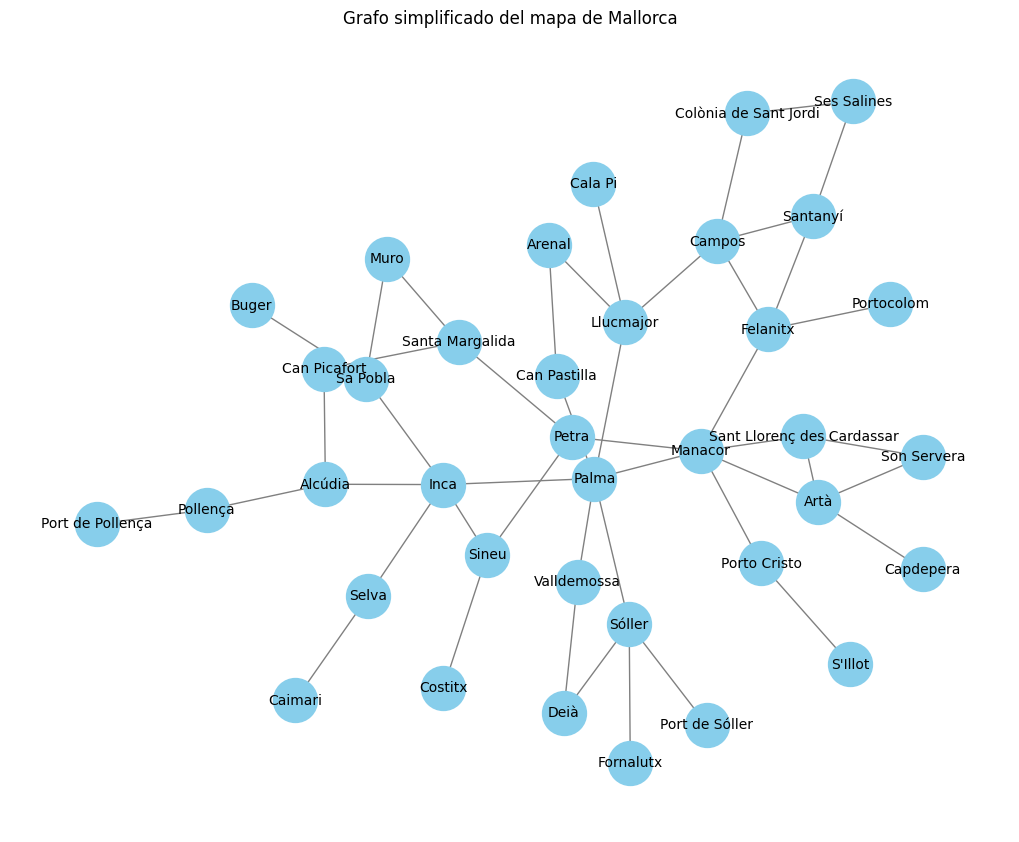

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# Crear el grafo
G = nx.Graph()

# Añadir nodos (ciudades y pueblos)
G.add_nodes_from(graph_mallorca.keys())

# Añadir aristas (conexiones)
for city, connected_cities in graph_mallorca.items():
    for connected_city in connected_cities:
        G.add_edge(city, connected_city)

# Dibujar el grafo
plt.figure(figsize=(10, 8))
pos = nx.kamada_kawai_layout(G)
nx.draw(G, pos, with_labels=True, node_size=1000, node_color='skyblue', font_size=10, edge_color='gray')
plt.title('Grafo simplificado del mapa de Mallorca')
plt.show()

In [ ]:
def dfs(graph, start, goal, visited=None):
    if visited is None:
        visited = set()
    visited.add(start)

    if start == goal:
        return [start]

    for neighbor in graph.get(start, []):
        if neighbor not in visited:
            path = dfs(graph, neighbor, goal, visited)
            if path:
                return [start] + path

    return None

In [ ]:
from collections import deque

def bfs(graph, start, goal):
    visited = set()
    queue = deque([[start]]) # Queue stores paths

    while queue:
        path = queue.popleft()
        node = path[-1]

        if node == goal:
            return path

        if node not in visited:
            visited.add(node)
            for neighbor in graph.get(node, []):
                new_path = list(path)
                new_path.append(neighbor)
                queue.append(new_path)

    return None

In [ ]:
start_city = 'Deià' # Ciudad inicial
goal_city = 'Cala Pi' # Ciudad final

# Encontrar un camino usando DFS
dfs_path = dfs(graph_mallorca, start_city, goal_city)
print(f"Camino encontrado por DFS de {start_city} a {goal_city}: {dfs_path}")

# Encontrar un camino usando BFS
bfs_path = bfs(graph_mallorca, start_city, goal_city)
print(f"Camino encontrado por BFS de {start_city} a {goal_city}: {bfs_path}")

Camino encontrado por DFS de Deià a Cala Pi: ['Deià', 'Valldemossa', 'Palma', 'Inca', 'Alcúdia', 'Can Picafort', 'Santa Margalida', 'Petra', 'Manacor', 'Felanitx', 'Campos', 'Llucmajor', 'Cala Pi']
Camino encontrado por BFS de Deià a Cala Pi: ['Deià', 'Valldemossa', 'Palma', 'Llucmajor', 'Cala Pi']


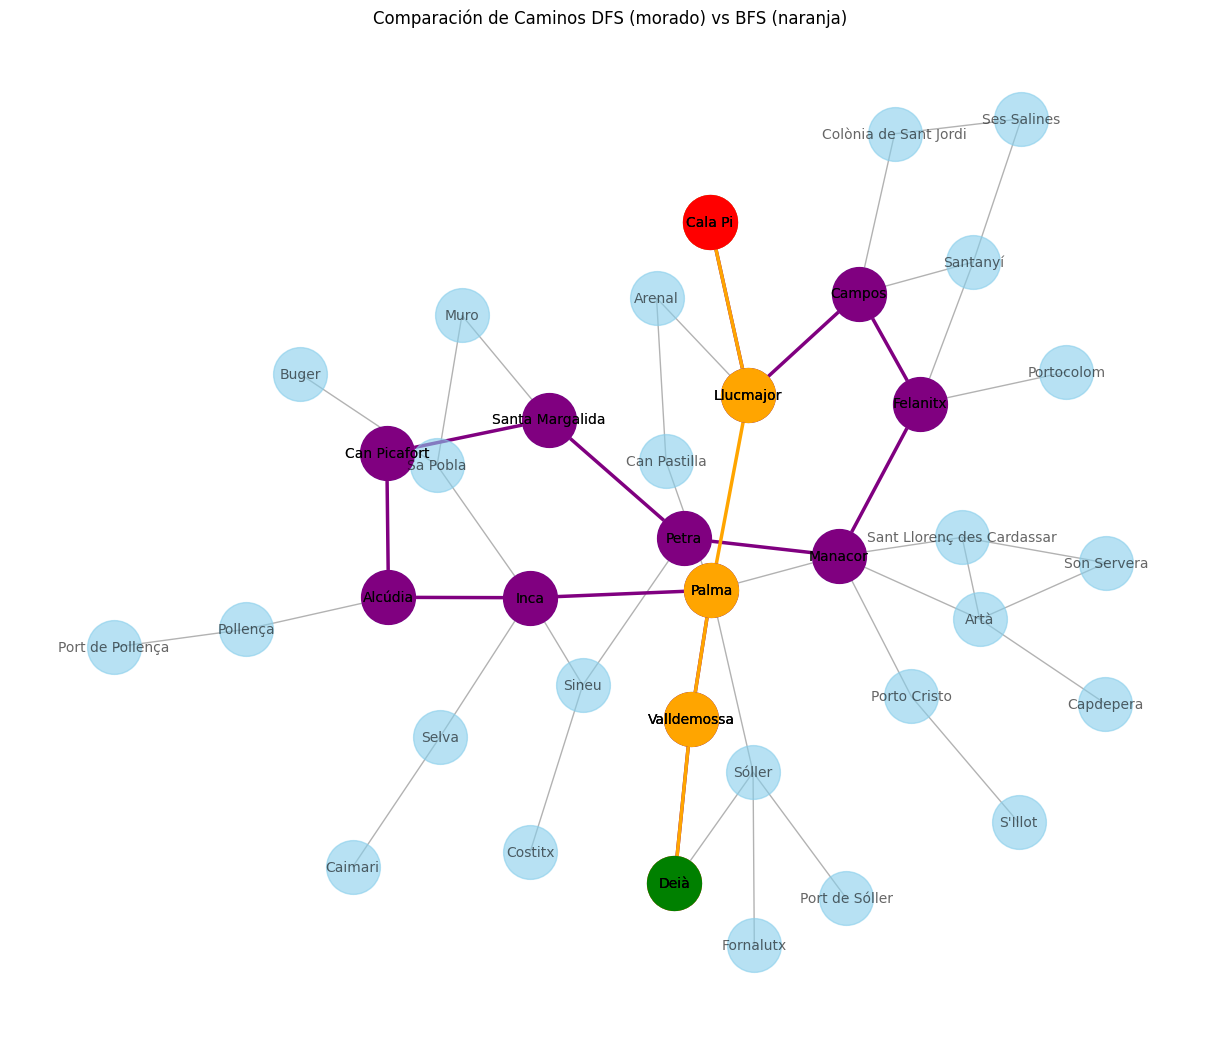

In [ ]:
# Dibujar el grafo con los caminos resaltados
plt.figure(figsize=(12, 10))
pos = nx.kamada_kawai_layout(G)  # Reutilizar el layout anterior

# Dibujar el grafo base
nx.draw(G, pos, with_labels=True, node_size=1500, node_color='skyblue', font_size=10, edge_color='gray', alpha=0.6)

# Resaltar el camino encontrado por DFS (en rosa)
if dfs_path:
    dfs_edges = [(dfs_path[i], dfs_path[i+1]) for i in range(len(dfs_path)-1)]
    nx.draw_networkx_nodes(G, pos, nodelist=dfs_path, node_color='purple', node_size=1500)
    nx.draw_networkx_edges(G, pos, edgelist=dfs_edges, edge_color='purple', width=2.5)
    nx.draw_networkx_labels(G, pos, labels={node: node for node in dfs_path}, font_size=10, font_color='black')


# Resaltar el camino encontrado por BFS (en naranja)
if bfs_path:
    bfs_edges = [(bfs_path[i], bfs_path[i+1]) for i in range(len(bfs_path)-1)]
    nx.draw_networkx_nodes(G, pos, nodelist=bfs_path, node_color='orange', node_size=1500)
    nx.draw_networkx_edges(G, pos, edgelist=bfs_edges, edge_color='orange', width=2.5)
    nx.draw_networkx_labels(G, pos, labels={node: node for node in bfs_path}, font_size=10, font_color='black')

# Reseltar ciudad inicial (verde) y ciudad final (rojo)

nx.draw_networkx_nodes(G, pos, nodelist=[start_city], node_color='green', node_size=1500)
nx.draw_networkx_nodes(G, pos, nodelist=[goal_city], node_color='red', node_size=1500)


plt.title('Comparación de Caminos DFS (morado) vs BFS (naranja)')
plt.show()

## Conclusión: Utilidad de DFS y BFS en el Ejemplo del Mapa de Mallorca

Al visualizar los caminos encontrados por los algoritmos DFS (en morado) y BFS (en naranja) en el grafo del mapa de Mallorca, podemos observar claramente la diferencia en su estrategia de búsqueda y en el resultado obtenido.

En este escenario específico de encontrar un camino entre dos ciudades en un grafo no ponderado (donde cada conexión tiene el mismo "costo"), **el algoritmo BFS demuestra ser el más útil para encontrar la ruta más corta en términos del número de ciudades intermedias**.

La razón de esto radica en la naturaleza de la búsqueda de BFS. Al explorar el grafo nivel por nivel, garantiza que todos los nodos a una distancia 'k' del nodo inicial son visitados antes de proceder a los nodos a distancia 'k+1'. Esto significa que la primera vez que el algoritmo encuentra el nodo objetivo, ha identificado automáticamente el camino con el menor número de aristas desde el origen.

Por otro lado, el algoritmo DFS prioriza la profundidad. Explora un camino lo más lejos posible antes de retroceder. Si bien esto es útil para otros tipos de problemas (como detectar ciclos o explorar todas las posibilidades), no garantiza encontrar el camino más corto en un grafo no ponderado. Como se vio en la visualización, el camino encontrado por DFS puede ser considerablemente más largo que el de BFS, ya que sigue una trayectoria profunda en una dirección antes de dar con el destino.

En resumen, para problemas de búsqueda del camino más corto en grafos donde el peso de las aristas no es un factor (grafos no ponderados), BFS es la opción preferible. DFS, aunque igualmente importante, es más adecuado para exploraciones que priorizan la profundidad o la completitud sobre la distancia mínima. En el contexto de encontrar la ruta más eficiente en términos de paradas en nuestro mapa simplificado de Mallorca, BFS es claramente el algoritmo más ventajoso.

## Introducción a los Algoritmos de Búsqueda de Caminos: BFS, Greedy Best-First Search y A\*

La búsqueda de caminos es un problema fundamental en inteligencia artificial y ciencias de la computación, que consiste en encontrar una secuencia de movimientos o transiciones desde un punto de inicio hasta un punto final en un espacio definido (como un grafo o un grid). Varios algoritmos han sido desarrollados para resolver este problema, cada uno con sus propias estrategias y propiedades. Aquí exploraremos tres de ellos: Búsqueda en Amplitud (BFS), Greedy Best-First Search (GBFS) y A\* Search.

### Búsqueda en Amplitud (BFS - Breadth-First Search)

BFS es un algoritmo de búsqueda **no informada** que explora un grafo nivel por nivel. Comienza en el nodo raíz y visita a todos sus vecinos directos, luego a los vecinos de esos vecinos, y así sucesivamente. Utiliza una cola para gestionar los nodos a visitar.

*   **Utilidad:** Encontrar el camino más corto (en número de pasos) en grafos no ponderados.
*   **Completitud:** Es completo (encontrará un camino si existe).
*   **Optimalidad:** Es óptimo (encuentra el camino más corto) en grafos no ponderados.

### Greedy Best-First Search (GBFS)

GBFS es un algoritmo de búsqueda **informada** (heurística). Utiliza una función heurística (`h`) que estima el costo desde el nodo actual hasta el nodo objetivo. Siempre expande el nodo que parece más cercano al objetivo según esta heurística. Utiliza una cola de prioridad.

*   **Utilidad:** Encontrar un camino rápidamente.
*   **Completitud:** No es completo en general (puede quedar atrapado en ciclos si no se manejan nodos visitados).
*   **Optimalidad:** No es óptimo (no garantiza el camino más corto).

### A\* Search

A\* es un algoritmo de búsqueda **informada** que combina el costo del camino recorrido desde el inicio hasta el nodo actual (`g`) con la estimación heurística desde el nodo actual hasta el objetivo (`h`). Prioriza la expansión de nodos basándose en el costo total estimado (`f = g + h`). Utiliza una cola de prioridad.

*   **Utilidad:** Encontrar el camino más corto/óptimo de manera eficiente.
*   **Completitud:** Es completo si el espacio de búsqueda es finito y no hay costos de arista negativos.
*   **Optimalidad:** Es óptimo si la heurística es admisible (nunca sobreestima el costo real).

### Diferencias Clave:

La principal diferencia radica en cómo deciden qué nodo expandir a continuación: BFS lo hace por niveles, GBFS se basa solo en la estimación heurística al objetivo, y A\* considera tanto el costo incurrido como la estimación heurística restante.


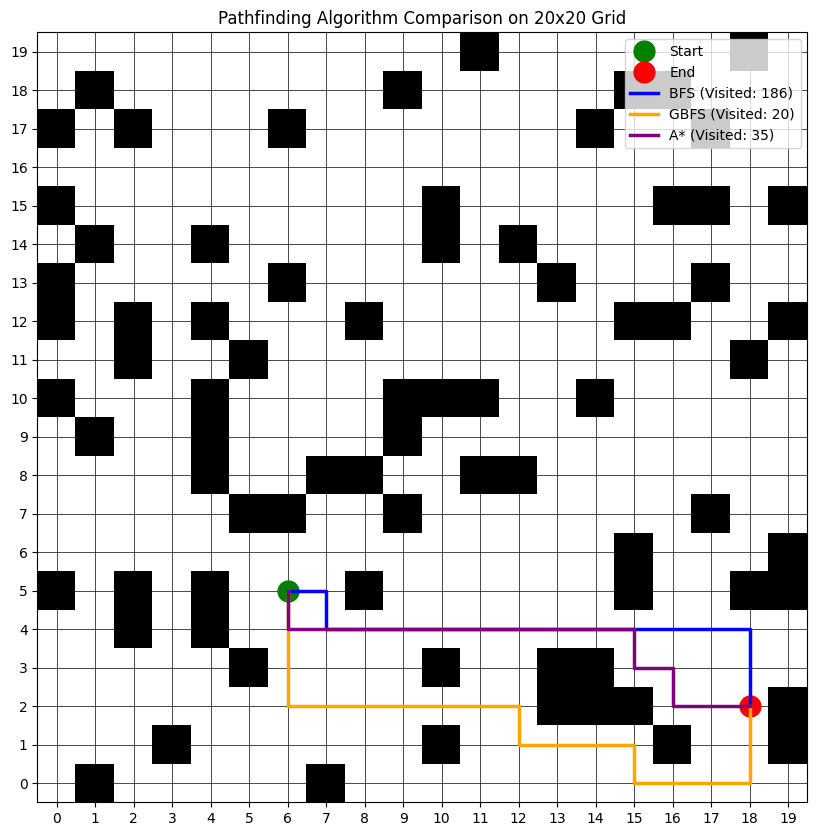

In [ ]:
import matplotlib.pyplot as plt
import random
from collections import deque
import numpy as np
import heapq

# --- Functions (Assuming these are defined in previous cells or should be included here) ---
# Re-defining functions needed by this cell to ensure they are available
def heuristic(a, b):
    """Calculates the Manhattan distance between two points."""
    return abs(a[0] - b[0]) + abs(a[1] - b[1])

def bfs_grid(grid, start, end):
    """
    Performs Breadth-First Search on a grid to find a path from start to end.

    Args:
        grid: A 2D list representing the grid, where 0 is passable and 1 is an obstacle.
        start: A tuple (row, col) for the starting position.
        end: A tuple (row, col) for the ending position.

    Returns:
        A tuple containing:
        - A list of (row, col) tuples representing the path from start to end,
          or None if no path is found.
        - The number of nodes visited during the search.
    """
    rows, cols = len(grid), len(grid[0])
    queue = deque([[start]]) # Queue stores paths
    visited = set()
    visited.add(start)
    visited_count = 0

    # Define possible movements (up, down, left, right)
    movements = [(0, 1), (0, -1), (1, 0), (-1, 0)]

    while queue:
        path = queue.popleft()
        current_node = path[-1]

        visited_count += 1 # Count the node as visited when popped from queue

        if current_node == end:
            return path, visited_count

        r, c = current_node

        for dr, dc in movements:
            new_r, new_c = r + dr, c + dc

            # Check if the new position is within grid bounds
            if 0 <= new_r < rows and 0 <= new_c < cols:
                # Check if the new position is not an obstacle and not visited
                if grid[new_r][new_c] == 0 and (new_r, new_c) not in visited:
                    visited.add((new_r, new_c))
                    new_path = list(path)
                    new_path.append((new_r, new_c))
                    queue.append(new_path)

    return None, visited_count # Return None path and the count if no path found

def gbfs_grid(grid, start, end):
    """
    Performs Greedy Best-First Search on a grid to find a path from start to end.

    Args:
        grid: A 2D list representing the grid, where 0 is passable and 1 is an obstacle.
        start: A tuple (row, col) for the starting position.
        end: A tuple (row, col) for the ending position.

    Returns:
        A tuple containing:
        - A list of (row, col) tuples representing the path from start to end,
          or None if no path is found.
        - The number of nodes visited during the search.
    """
    rows, cols = len(grid), len(grid[0])
    # Priority queue stores tuples: (heuristic_value, node, path)
    # The heuristic value is used to prioritize nodes.
    priority_queue = [(heuristic(start, end), start, [start])]
    visited = set()
    visited.add(start)
    visited_count = 0

    # Define possible movements (up, down, left, right)
    movements = [(0, 1), (0, -1), (1, 0), (-1, 0)]

    while priority_queue:
        # Pop the node with the lowest heuristic value
        _, current_node, path = heapq.heappop(priority_queue)

        visited_count += 1 # Count the node as visited when popped from queue

        if current_node == end:
            return path, visited_count

        r, c = current_node

        for dr, dc in movements:
            new_r, new_c = r + dr, c + dc
            neighbor = (new_r, new_c)

            # Check if the new position is within grid bounds
            if 0 <= new_r < rows and 0 <= new_c < cols:
                # Check if the new position is not an obstacle and not visited
                if grid[new_r][new_c] == 0 and neighbor not in visited:
                    visited.add(neighbor)
                    new_path = list(path)
                    new_path.append(neighbor)
                    # Calculate heuristic for the neighbor
                    h_value = heuristic(neighbor, end)
                    # Push the neighbor into the priority queue
                    heapq.heappush(priority_queue, (h_value, neighbor, new_path))

    return None, visited_count # Return None path and the count if no path found

def a_star_grid(grid, start, end):
    """
    Performs A* search on a grid to find the shortest path from start to end.

    Args:
        grid: A 2D list representing the grid, where 0 is passable and 1 is an obstacle.
        start: A tuple (row, col) for the starting position.
        end: A tuple (row, col) for the ending position.

    Returns:
        A tuple containing:
        - A list of (row, col) tuples representing the shortest path from start to end,
          or None if no path is found.
        - The number of nodes visited during the search.
    """
    rows, cols = len(grid), len(grid[0])
    # Priority queue stores tuples: (f_cost, g_cost, node, path)
    # f_cost = g_cost + heuristic
    priority_queue = [(heuristic(start, end), 0, start, [start])]

    # Keep track of the cheapest path found so far to each node
    g_costs = {start: 0}
    visited_count = 0

    # Define possible movements (up, down, left, right) and their cost
    movements = [(0, 1), (0, -1), (1, 0), (-1, 0)]
    step_cost = 1

    while priority_queue:
        # Pop the node with the lowest f_cost
        f_cost, current_g_cost, current_node, path = heapq.heappop(priority_queue)

        visited_count += 1 # Count the node as visited when popped from queue

        if current_node == end:
            return path, visited_count

        r, c = current_node

        for dr, dc in movements:
            new_r, new_c = r + dr, c + dc
            neighbor = (new_r, new_c)

            # Check if the new position is within grid bounds
            if 0 <= new_r < rows and 0 <= new_c < cols:
                # Check if the new position is not an obstacle
                if grid[new_r][new_c] == 0:
                    # Calculate the tentative g-cost to reach the neighbor
                    tentative_g_cost = current_g_cost + step_cost

                    # If the neighbor has not been visited, or if the tentative g-cost
                    # is lower than the previously recorded g-cost for that neighbor
                    if neighbor not in g_costs or tentative_g_cost < g_costs[neighbor]:
                        g_costs[neighbor] = tentative_g_cost
                        f_cost = tentative_g_cost + heuristic(neighbor, end)
                        new_path = list(path)
                        new_path.append(neighbor)
                        # Push the neighbor into the priority queue
                        heapq.heappush(priority_queue, (f_cost, tentative_g_cost, neighbor, new_path))

    return None, visited_count # Return None path and the count if no path found

def generate_solvable_grid(rows, cols, obstacle_probability):
    """
    Generates a solvable grid with random obstacles, start, and end points.

    Args:
        rows: The number of rows in the grid.
        cols: The number of columns in the grid.
        obstacle_probability: The probability (between 0 and 1) of a cell being an obstacle.

    Returns:
        A tuple containing:
        - The generated 2D list representing the grid.
        - The start node (row, col).
        - The end node (row, col).
    """

    def is_solvable(grid, start, end):
        """Checks if there is a path from start to end in the grid using BFS."""
        rows, cols = len(grid), len(grid[0])
        queue = deque([start])
        visited = set()
        visited.add(start)

        movements = [(0, 1), (0, -1), (1, 0), (-1, 0)]

        while queue:
            current_node = queue.popleft()

            if current_node == end:
                return True

            r, c = current_node

            for dr, dc in movements:
                new_r, new_c = r + dr, c + dc
                neighbor = (new_r, new_c)

                if 0 <= new_r < rows and 0 <= new_c < cols:
                    if grid[new_r][new_c] == 0 and neighbor not in visited:
                        visited.add(neighbor)
                        queue.append(neighbor)

        return False

    while True:
        # Initialize grid with all passable cells
        grid = [[0 for _ in range(cols)] for _ in range(rows)]

        # Randomly place obstacles
        for r in range(rows):
            for c in range(cols):
                if random.random() < obstacle_probability:
                    grid[r][c] = 1

        # Choose random start and end points
        start = (random.randint(0, rows - 1), random.randint(0, cols - 1))
        end = (random.randint(0, rows - 1), random.randint(0, cols - 1))

        # Ensure start and end are not obstacles
        grid[start[0]][start[1]] = 0
        grid[end[0]][end[1]] = 0

        # Check if the grid is solvable
        if is_solvable(grid, start, end):
            return grid, start, end


# --- Visualization Function ---
def draw_grid_paths(grid, start, end, paths_info, title="Grid Paths Comparison"):
    """
    Visualizes the grid, start, end, and multiple optional paths with visited counts in legend.

    Args:
        grid: A 2D list representing the grid, where 0 is passable and 1 is an obstacle.
        start: A tuple (row, col) for the starting position.
        end: A tuple (row, col) for the ending position.
        paths_info: A list of tuples, where each tuple is (path, visited_count, label, color).
                    path: List of (row, col) tuples for the path.
                    visited_count: The number of nodes visited.
                    label: The name of the algorithm (e.g., "BFS").
                    color: The color for the path line.
        title: The title of the plot.
    """
    fig, ax = plt.subplots(figsize=(10, 10))

    # Display the grid
    ax.imshow(grid, cmap='Greys', origin='upper')

    # Mark start and end points
    ax.plot(start[1], start[0], 'go', markersize=15, label='Start') # 'go' for green circle
    ax.plot(end[1], end[0], 'ro', markersize=15, label='End')     # 'ro' for red circle

    # Plot the paths
    for path, visited_count, label, color in paths_info:
        if path:
            path_x = [p[1] for p in path]
            path_y = [p[0] for p in path]
            ax.plot(path_x, path_y, color=color, linewidth=2.5, label=f'{label} (Visited: {visited_count})')
            # Mark nodes on the path (optional, adjust size/style as needed)
            # ax.plot(path_x, path_y, 'o', color=color, markersize=5)


    # Set grid lines and ticks
    ax.set_xticks(range(len(grid[0])))
    ax.set_yticks(range(len(grid)))
    ax.grid(True, which='both', color='black', linewidth=0.5)

    # Set title and legend
    ax.set_title(title)
    ax.legend()

    # Invert y-axis to match grid indexing (row 0 at the top)
    ax.invert_yaxis()
    ax.set_aspect('equal', adjustable='box') # Make cells square

# --- Main Execution ---
# Generate a solvable 20x20 grid with random start and end points
rows, cols = 20, 20
obstacle_prob = 0.2
solvable_grid, start_node, end_node = generate_solvable_grid(rows, cols, obstacle_prob)

# Execute the pathfinding algorithms and get visited counts
bfs_path, bfs_visited_count = bfs_grid(solvable_grid, start_node, end_node)
gbfs_path, gbfs_visited_count = gbfs_grid(solvable_grid, start_node, end_node)
a_star_path, a_star_visited_count = a_star_grid(solvable_grid, start_node, end_node)

# Prepare the data for visualization
paths_to_draw = [
    (bfs_path, bfs_visited_count, 'BFS', 'blue'),
    (gbfs_path, gbfs_visited_count, 'GBFS', 'orange'),
    (a_star_path, a_star_visited_count, 'A*', 'purple')
]

# Draw the combined grid and paths
draw_grid_paths(solvable_grid, start_node, end_node, paths_to_draw, title="Pathfinding Algorithm Comparison on 20x20 Grid")

plt.show()

## Resumen de la Conclusión

En los ejemplos de comparación de búsqueda de caminos que hemos realizado en el grid:

*   **BFS** garantizó encontrar el camino más corto, pero fue el que visitó la mayor cantidad de nodos para hacerlo.
*   **GBFS** fue el más eficiente en términos de nodos visitados, encontrando un camino muy rápidamente, aunque no siempre se garantiza que sea el más corto.
*   **A\*** encontró el mismo camino óptimo que BFS (cuando la heurística es admisible), pero lo hizo de manera más eficiente (visitando menos nodos) que BFS.

Esto demuestra que BFS es robusto para la optimalidad en grafos no ponderados, GBFS es rápido para encontrar *un* camino, y A\* ofrece un balance efectivo entre optimalidad y eficiencia en la exploración. La elección depende de si la velocidad de encontrar *cualquier* camino es prioritaria o si se necesita el camino **más corto/óptimo**.